CELL 1

Load necessary tools and configure hardware. 
Make sure to use the GPU - Nvidia RTX 1650 available

In [1]:
# import libraries

# core libraries for computations and utilies (pre-trained model)
import torch
import torchvision
# model
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
# handle images
from PIL import Image
# high-level mathematical functions, arrays, matrices
import numpy as np
# plot image and draw boxes
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# make sure GPU is used
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# define COCO Class names - index 47 is cup
# when the model detects an object, it outputs its assigned number (index in "dictionary")
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

CUP_CLASS_INDEX = COCO_INSTANCE_CATEGORY_NAMES.index('cup')
print(f"Cup Class Index: {CUP_CLASS_INDEX}")

Using device: cuda
Cup Class Index: 47


CELL 2

Metrics used to measure the detections: IoU

In [5]:
"""
Intersection over union

IoU = 1.0 -> perfectly alligned
IoU = 0.0 -> boxes don't intersect at all
IoU > 0.5 -> consider correct detection
"""
def calculate_iou(boxA, boxB):
    # coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    intersectionArea = max(0, xB - xA) * max(0, yB - yA)

    # area of the prediction and ground-truth rectangles
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = intersectionArea / float(boxAArea + boxBArea - intersectionArea)
    return iou

"""
Compute TP, FP, FN for an image

- prediction boxes, prediction scores, ground truth boxes 
"""
def evaluate_image(pred_boxes, pred_scores, gt_boxes, iou_threshold=0.5):
    tp = 0
    fp = 0
    fn = 0

    # keep track of unmatched ground truth boxes
    unmatched_gt = list(range(len(gt_boxes)))

    for i, pred_box in enumerate(pred_boxes):
        best_iou = 0
        best_gt_idx = -1

        for gt_idx in unmatched_gt:
            iou = calculate_iou(pred_box, gt_boxes[gt_idx])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold:
            tp += 1
            unmatched_gt.remove(best_gt_idx)
        else:
            fp += 1

    # if there are ground truth boxes left unmatched => false negative (the model missed the cup)
    fn = len(unmatched_gt)

    return tp, fp, fn

CELL 3

Model evaluation

In [6]:
# load model and set to evaluation mode
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
model.to(device)
model.eval()

# load image
image_path = '../mug_coco_yolo/images/val2017/000000002431.jpg' 
image = Image.open(image_path).convert("RGB")

# convert to tensor (data structure in PyTorch), make size 1, and send to GPU
image_tensor = F.to_tensor(image).unsqueeze(0).to(device)

# defined manually the ground truth box/es
# format: [x_min, y_min, x_max, y_max]
ground_truth_boxes = [
    [100, 150, 300, 400]
]

# run inference
with torch.no_grad():
    prediction = model(image_tensor)

# filter results by cup
pred_boxes = prediction[0]['boxes'].cpu().numpy()
pred_labels = prediction[0]['labels'].cpu().numpy()
pred_scores = prediction[0]['scores'].cpu().numpy()

# keep cup predictions with high score
score_threshold = 0.5
mask = (pred_labels == CUP_CLASS_INDEX) & (pred_scores > score_threshold)

filtered_boxes = pred_boxes[mask]
filtered_scores = pred_scores[mask]

print(f"Model found {len(filtered_boxes)} cups with score > {score_threshold}")

Model found 4 cups with score > 0.5


CELL 4

Compute metrics to compare the model's predictions with the manually set ground truths

METRICS REPORT:
True Positives (TP): 0
False Positives (FP): 4
False Negatives (FN): 1
Precision: 0.00
Recall: 0.00


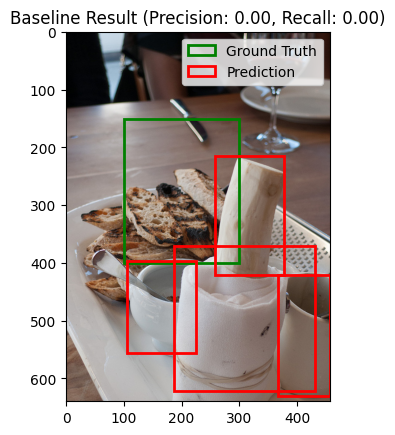

In [7]:
tp, fp, fn = evaluate_image(filtered_boxes, filtered_scores, ground_truth_boxes, iou_threshold=0.5)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print("METRICS REPORT:")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

fig, ax = plt.subplots(1)
ax.imshow(image)

for box in ground_truth_boxes:
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                             linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
    ax.add_patch(rect)

for box in filtered_boxes:
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                             linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
    ax.add_patch(rect)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.title(f"Baseline Result (Precision: {precision:.2f}, Recall: {recall:.2f})")
plt.show()

CELL 5

Yolo to Faster RCNN Dataset class
- handle txt parsing by converting the coordinates to loaded model requirements

In [9]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import glob

class YoloCupDataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        
        # Get list of all image files (sorting ensures alignment)
        self.img_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
        
    def __getitem__(self, index):
        # 1. Load Image
        img_path = self.img_files[index]
        img = Image.open(img_path).convert("RGB")
        
        # Get actual image size (needed to un-normalize the YOLO coordinates)
        w_img, h_img = img.size
        
        # 2. Derive Label Path from Image Path
        # Example: images/val2017/001.jpg -> labels/val2017/001.txt
        filename = os.path.basename(img_path)
        label_filename = filename.replace(".jpg", ".txt")
        label_path = os.path.join(self.label_dir, label_filename)
        
        boxes = []
        labels = []
        
        # 3. Read the YOLO .txt file
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                # YOLO format: class x_center y_center width height (normalized)
                class_id = int(parts[0])
                x_c_n = float(parts[1])
                y_c_n = float(parts[2])
                w_n = float(parts[3])
                h_n = float(parts[4])
                
                # CONVERSION MATH: Normalized -> Absolute Pixel Coordinates
                # 1. Convert center/width to absolute pixels
                x_c = x_c_n * w_img
                y_c = y_c_n * h_img
                w_box = w_n * w_img
                h_box = h_n * h_img
                
                # 2. Convert Center (x,y) to Top-Left/Bottom-Right (x_min, y_min, x_max, y_max)
                x_min = x_c - (w_box / 2)
                y_min = y_c - (h_box / 2)
                x_max = x_c + (w_box / 2)
                y_max = y_c + (h_box / 2)
                
                boxes.append([x_min, y_min, x_max, y_max])
                # We assume class_id 0 in your txt is 'cup'. 
                # Faster R-CNN treats 0 as background, so we usually shift classes by +1,
                # but since we are just detecting cups, we can force the label to 1.
                labels.append(1) 

        # 4. Handle Empty Labels (Images with no cups)
        if len(boxes) == 0:
            # Create a placeholder box (convention for empty images in some trainers, 
            # but ideally you just skip or handle empty tensors)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([index])
        
        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.img_files)

def get_transform():
    return torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
    ])

# --- VERIFICATION ---
# Define your paths
val_img_dir = '../mug_coco_yolo/images/val2017'
val_label_dir = '../mug_coco_yolo/labels/val2017'

# Create Dataset
dataset_val = YoloCupDataset(val_img_dir, val_label_dir, get_transform())

# Test it on the first image
img, target = dataset_val[4]
print(f"Loaded Image: {img.shape}")
print(f"Transformed Boxes (x_min, y_min, x_max, y_max): \n{target['boxes']}")

Loaded Image: torch.Size([3, 427, 640])
Transformed Boxes (x_min, y_min, x_max, y_max): 
tensor([[  3.8403, 118.9799,  63.3302, 214.9401],
        [490.9101, 166.8101, 556.4704, 233.3102]])


CELL 6

Baseline model evaluation 
- run model on every image in the validation set

In [ ]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm  # Import progress bar library

# Keep this function GLOBAL to avoid Windows errors
def collate_fn(batch):
    return tuple(zip(*batch))

def evaluate_entire_dataset(model, dataset, device, score_threshold=0.5, iou_threshold=0.5):
    # 1. Create DataLoader
    data_loader = DataLoader(
        dataset, 
        batch_size=4, 
        shuffle=False, 
        num_workers=0,
        collate_fn=collate_fn
    )
    
    print(f"Starting evaluation on {len(dataset)} images...")
    
    # Trackers for global metrics
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    model.eval()
    
    # Wrap data_loader with tqdm for the progress bar
    loader_with_progress = tqdm(data_loader, desc="Evaluating", unit="batch")
    
    with torch.no_grad():
        for images, targets in loader_with_progress:
            # Move images to GPU
            images = list(image.to(device) for image in images)
            
            # Get Predictions
            predictions = model(images)
            
            # Loop through each image in the batch
            for i, prediction in enumerate(predictions):
                pred_boxes = prediction['boxes'].cpu().numpy()
                pred_scores = prediction['scores'].cpu().numpy()
                pred_labels = prediction['labels'].cpu().numpy()
                
                # Check for Baseline (47) or Fine-Tuned (1)
                if 47 in pred_labels: 
                    target_class = 47
                else: 
                    target_class = 1

                mask = (pred_labels == target_class) & (pred_scores > score_threshold)
                filtered_preds = pred_boxes[mask]
                filtered_scores = pred_scores[mask]
                
                # Get Ground Truth
                gt_boxes = targets[i]['boxes'].numpy()
                
                # Calculate Metrics
                tp, fp, fn = evaluate_image(filtered_preds, filtered_scores, gt_boxes, iou_threshold)
                
                total_tp += tp
                total_fp += fp
                total_fn += fn
                
            # Optional: Update progress bar description with current precision
            curr_prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
            loader_with_progress.set_postfix(precision=f"{curr_prec:.2f}")

    # Calculate Global Metrics
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    
    return precision, recall

# --- RUN THE EVALUATION ---
if len(dataset_val) > 0:
    baseline_precision, baseline_recall = evaluate_entire_dataset(
        model, 
        dataset_val, 
        device
    )

    print("\n" + "="*30)
    print(f"BASELINE MODEL RESULTS")
    print("="*30)
    print(f"Global Precision: {baseline_precision:.4f}")
    print(f"Global Recall:    {baseline_recall:.4f}")
    print("="*30)
else:
    print("Error: Dataset is empty.")

Starting evaluation on 1390 images...


Evaluating:   0%|          | 0/348 [00:00<?, ?batch/s]